In [ ]:
import enn554.pv as pv
import enn554.constants as const
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1
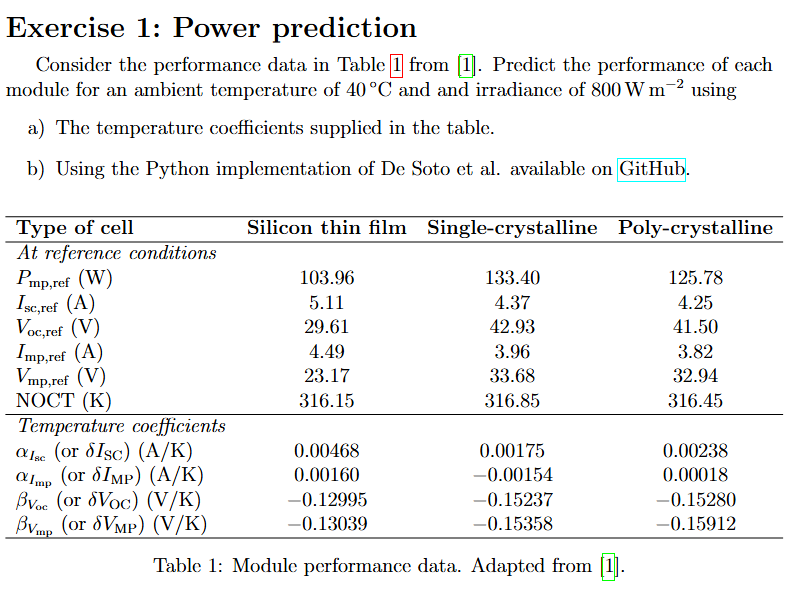

## Part a) 
I will do the Single-crystalline cell with the others left as an exercise to the reader. There is not power coefficient supplied, so we use the change in MPP. Note that the reference condition in De Soto is STC.

In [ ]:
G_ref, T_ref = 1000, 273.15+25 # W/m2, K
I_mp_ref, δI_mp = 3.96, -0.00154 # A, A/K
V_mp_ref, δV_mp = 33.68, -0.15358 # V, V/K
NOCT,G_NOCT = 316.85,800


# compute new cell temperature
G = 950
Tc = (40+273.15) + (NOCT - 293.15)/G_NOCT * G
print(f'Tc = {Tc:.2f}K, {Tc-273.15:.2f}C')

In [ ]:
I_mp = I_mp_ref + δI_mp * (Tc-T_ref)
V_mp = V_mp_ref + δV_mp * (Tc-T_ref)
P_mp = I_mp * V_mp
print(f'New MPP: ({V_mp:.2f}V, {I_mp:.2f}A)')
print(f'New Power: {P_mp:.2f}W')

## Part b) 
I will do this using the python module for De Soto. 

In [ ]:
module = pv.DeSotoModel(Ns=72.0,Isc_ref=4.37,Voc_ref=42.93,Imp_ref=I_mp_ref,Vmp_ref=V_mp_ref,delta_Isc=0.00175,delta_Voc=-0.15237)
vmp,imp,pmp = module.mpp(G=G,T_C=Tc-273.15)
print(f'New MPP: ({vmp:.2f}V, {imp:.2f}A)')
print(f'New Power: {pmp:.2f}W')

Visualize

In [ ]:
ax = module.plot_iv()
module.plot_iv(ax=ax,G=G,T_C=Tc-273.15)
ax.plot(vmp,imp,'r*',markersize=10,label="MPP")

# Exercise 2
Let $n$ be the number of modules. The shaded voltage is
\begin{align}
    \Delta V \approx \frac{V}{n} + (I-I_{L,shaded})R_p
\end{align}
where $V$ is the voltage when all four modules are in the same solar irradiance. This equation governs the case where $I_{L,shaded} < I$. In the other zone, the shaded module will increase voltage

In [ ]:
Tc = 273.15+25 + (NOCT - 293.15)/G_NOCT * 950
Tc_C = Tc - 273.15
module = pv.DeSotoModel(Ns=72.0,Isc_ref=4.37,Voc_ref=42.93,Imp_ref=I_mp_ref,
                              Vmp_ref=V_mp_ref,delta_Isc=0.00175,delta_Voc=-0.15237)

# sunny modules
v,i,p = module.iv_curve(G=800,T_C=Tc_C,n_points=2000)
idx_mpp = np.argmax(p)

# shading effect
ISH = module.current(V=0,G=120,T_C=Tc_C)
_, _, _, _, Rsh = module.translate(G=120, T_C=Tc_C)
V_shaded_module = np.array([module.voltage(I=ii,G=120,T_C=Tc_C) for ii in i]) # voltage of the shaded module
VSH = 3*v # voltage of the non-shaded modules
VSH[i<=ISH] += V_shaded_module[i<=ISH]
VSH[i>=ISH] -= v[i>=ISH]/module.Ns + (i[i>=ISH]-ISH)*Rsh
VSH[VSH<0] = np.nan
idx_mpp_s = np.nanargmax(i*VSH)



Plotting

In [ ]:
fig,ax = plt.subplots()
P0,Ps = 4*v[idx_mpp]*i[idx_mpp],VSH[idx_mpp_s]*i[idx_mpp_s]
ax.plot(4*v,i,label=f'No shading (P={P0:.1f}W)')
ax.plot(VSH,i,label=f'With shading (P={Ps:.1f}W)')
ax.plot(4*v[idx_mpp],i[idx_mpp],'r*',markersize=10)
ax.plot(VSH[idx_mpp_s],i[idx_mpp_s],'r*',markersize=10)
ax.set_xlim((0,160))
ax.set_ylim((0,4))
ax.legend()

The overall POA for the sunny case is $4\cdot A_{mod} \cdot 800$ whereas in the shaded case it's  $A_{mod} \cdot (3 \times 800 + 120)$. This yields an overall reduction of 

In [ ]:
poa_loss_fraction = 1-(3*800+120)/4/800
print(f'Lost {poa_loss_fraction*100:.1f}% of the INCIDENT power')
print(f'... but output loss is {(1-Ps/P0)*100:.1f}% original power!')

The loss is much higher than a simple "lost POA" calculation would suggest. Adding bypass diodes would greatly improve the performance. 